In [1]:
# 开启自动重载，修改 Analysis.py 后自动生效
%load_ext autoreload
%autoreload 2

import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, JSON

# 插入你的模块路径
sys.path.insert(0, "/data2/home/luodh/Git-workflow/Workflow_for_vasp_catalysis/")

# 导入你写的类和调度器
from vasp_analysis_mod.core.Analysis import VaspAnalysisDispatcher

# 定义测试文件夹路径 (请确保路径正确)
RELAX_DIR   = Path("/data2/home/luodh/Test/VaspAnalysis-Test/Relax-Test")
DOS_DIR     = Path("/data2/home/luodh/Test/VaspAnalysis-Test/Doscar-Text")
LOBSTER_DIR = Path("/data2/home/luodh/Test/VaspAnalysis-Test/Lobster-Text")

# 设置画图全局样式
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12


In [2]:
import json

# 假设 RELAX_DIR 和 VaspAnalysisDispatcher 已经在上文定义
# RELAX_DIR = "./your_test_directory"

print("==================================================")
print("测试 1: 获取结构信息 (task_type='structure_info')")
print("==================================================")
resp_struct_json = VaspAnalysisDispatcher.dispatch(
    task_type="structure_info",
    work_dir=RELAX_DIR
)
resp_struct = json.loads(resp_struct_json)

if resp_struct["success"]:
    print("✅ 结构解析成功！")
    print(f"总原子数: {resp_struct['data']['totalAtoms']}")
    print(f"包含元素: {resp_struct['data']['elements']}")
    print("晶格信息:")
    print(json.dumps(resp_struct['data']['lattice'], indent=2))
else:
    print("❌ 结构解析失败:", resp_struct["message"])


print("\n==================================================")
print("测试 2: 获取结构优化信息 (task_type='relax')")
print("==================================================")
resp_relax_json = VaspAnalysisDispatcher.dispatch(
    task_type="relax",
    work_dir=RELAX_DIR,
    get_site_mag=True  # 👈 开启位点磁矩解析
)
resp_relax = json.loads(resp_relax_json)

if resp_relax["success"]:
    data = resp_relax["data"]
    print("✅ 优化结果解析成功！")
    print(f"是否收敛: {data['converged']}")
    print(f"总电子数: {data['total_electrons']}")
    print(f"总磁矩: {data['total_magnetization']} μB")
    print(f"最终能量: {data['final_energy_eV']} eV")
    
    # 注意：根据你最新的代码，这里的键名是 final_force
    final_force = data.get('final_force')
    if final_force is not None:
        print(f"最终最大受力: {final_force:.4f} eV/Å")
    
    print(f"离子步数: {data['ionic_steps']}")
    
    print(f"\n📊 能量历史数据点数: {len(data['energy_history'])}")
    print(f"📊 dE 历史数据点数: {len(data['de_history'])}")
    print(f"📊 受力历史数据点数: {len(data.get('force_history', []))}")
    
    if data.get('warnings'):
        print("\n⚠️ 警告信息:")
        for w in data['warnings']:
            print(f"  - {w}")
    
    if data.get('site_magnetization'):
        print(f"\n🧲 成功提取 {len(data['site_magnetization'])} 个原子的位点磁矩！")
        print("前 3 个原子的磁矩信息:")
        for sm in data['site_magnetization'][:3]:
            print(f"  Atom {sm['atom_index']}: s={sm['s']}, p={sm['p']}, d={sm['d']}, Total={sm['tot']} μB")
    else:
        print("\n🧲 当前体系没有位点磁矩数据 (可能是非自旋极化计算)。")

    # ==================================================
    # 🌟 新增测试：检查初始和末态结构 (POSCAR / CONTCAR)
    # ==================================================
    print("\n==================================================")
    print("测试 3: 检查结构文本提取 (POSCAR & CONTCAR)")
    print("==================================================")
    
    init_struct = data.get("initial_structure")
    final_struct = data.get("final_structure")
    
    if init_struct:
        print("✅ 成功获取初始结构 (POSCAR)!")
        print(f"   化学式: {init_struct.get('formula')}")
        print(f"   体积: {init_struct.get('volume'):.2f} Å³")
        vasp_text = init_struct.get('vasp_text', '')
        print(f"   VASP 原生文本长度: {len(vasp_text)} 字符")
        # 打印前两行作为预览验证
        print(f"   文本预览 (前2行): {repr(vasp_text.splitlines()[:2])}")
    else:
        print("⚠️ 未找到初始结构 (POSCAR)")

    if final_struct:
        print("\n✅ 成功获取末态结构 (CONTCAR)!")
        print(f"   化学式: {final_struct.get('formula')}")
        print(f"   体积: {final_struct.get('volume'):.2f} Å³")
        vasp_text = final_struct.get('vasp_text', '')
        print(f"   VASP 原生文本长度: {len(vasp_text)} 字符")
    else:
        print("\n⚠️ 未找到末态结构 (CONTCAR)")

else:
    print("❌ 优化结果解析失败:", resp_relax["message"])


测试 1: 获取结构信息 (task_type='structure_info')
✅ 结构解析成功！
总原子数: 84
包含元素: ['Co', 'Ni', 'H', 'Rh', 'C']
晶格信息:
{
  "a": 8.308391439727421,
  "b": 11.749839855567046,
  "c": 29.07937003904598,
  "alpha": 90.0,
  "beta": 90.0,
  "gamma": 90.0
}

测试 2: 获取结构优化信息 (task_type='relax')
✅ 优化结果解析成功！
是否收敛: True
总电子数: 1107.0
总磁矩: -3.9350425 μB
最终能量: -241.68384 eV
最终最大受力: 0.5537 eV/Å
离子步数: 125

📊 能量历史数据点数: 125
📊 dE 历史数据点数: 125
📊 受力历史数据点数: 125

🧲 成功提取 84 个原子的位点磁矩！
前 3 个原子的磁矩信息:
  Atom 1: s=0.004, p=-0.005, d=2.051, Total=2.05 μB
  Atom 2: s=0.004, p=-0.004, d=2.053, Total=2.052 μB
  Atom 3: s=0.004, p=-0.004, d=2.071, Total=2.071 μB

测试 3: 检查结构文本提取 (POSCAR & CONTCAR)
✅ 成功获取初始结构 (POSCAR)!
   化学式: Co20Ni20H3Rh40C
   体积: 2838.79 Å³
   VASP 原生文本长度: 6571 字符
   文本预览 (前2行): ['Co20 Ni20 H3 Rh40 C1', '1.0']

✅ 成功获取末态结构 (CONTCAR)!
   化学式: Co20Ni20H3Rh40C
   体积: 2838.79 Å³
   VASP 原生文本长度: 10603 字符


In [3]:
print("\n🚀 [测试 2] 正在执行全量 DOS 解析与积分计算 (task: dos)...")

test_curves = [
    #{"id": "c1", "mode": "element", "element": "Pd", "orbital": "d", "label": "All Pd (Total d)", "color": "#1f77b4"},
    #{"id": "c2", "mode": "element", "element": "O", "orbital": "p", "label": "All O (Total p)", "color": "#ff7f0e"},
    {"id": "c3", "mode": "site", "site": 1, "orbital": "d", "label": "Site-1 Pd (d)", "color": "#d62728"},
    {"id": "c4", "mode": "site", "site": 2, "orbital": "d", "label": "Site-2 Pd (d)", "color": "#9467bd"}
]

dos_json_str = VaspAnalysisDispatcher.dispatch(
    task_type="dos",
    work_dir=DOS_DIR,
    curves=test_curves,
    erange=[-10, 10],
    show_tdos=False
)

dos_res = json.loads(dos_json_str)

# 💡 打印一下真实的 keys，看看 ApiResponse 返回了什么结构
print("🔍 接口返回的 Keys:", dos_res.keys())

# 兼容多种常见的 ApiResponse 成功状态判断
is_success = (
    dos_res.get("status") in ["success", 200, "200"] or 
    dos_res.get("code") == 200 or 
    dos_res.get("success") is True
)

if is_success:
    dos_data = dos_res["data"]
    print(f"✅ DOS 解析完美完成！")
    print(f"👉 能量点数量 (全量无损): {len(dos_data['energy'])}")
    print(f"👉 体系自旋极化 (ISPIN): {dos_data['ispin']}")
else:
    print(f"❌ DOS 解析失败: {dos_res.get('message')}")
    print("返回的完整数据:", dos_res)


🚀 [测试 2] 正在执行全量 DOS 解析与积分计算 (task: dos)...
🔍 接口返回的 Keys: dict_keys(['success', 'code', 'message', 'data'])
✅ DOS 解析完美完成！
👉 能量点数量 (全量无损): 3001
👉 体系自旋极化 (ISPIN): 2


📊 正在绘制 2 条 PDOS 曲线...


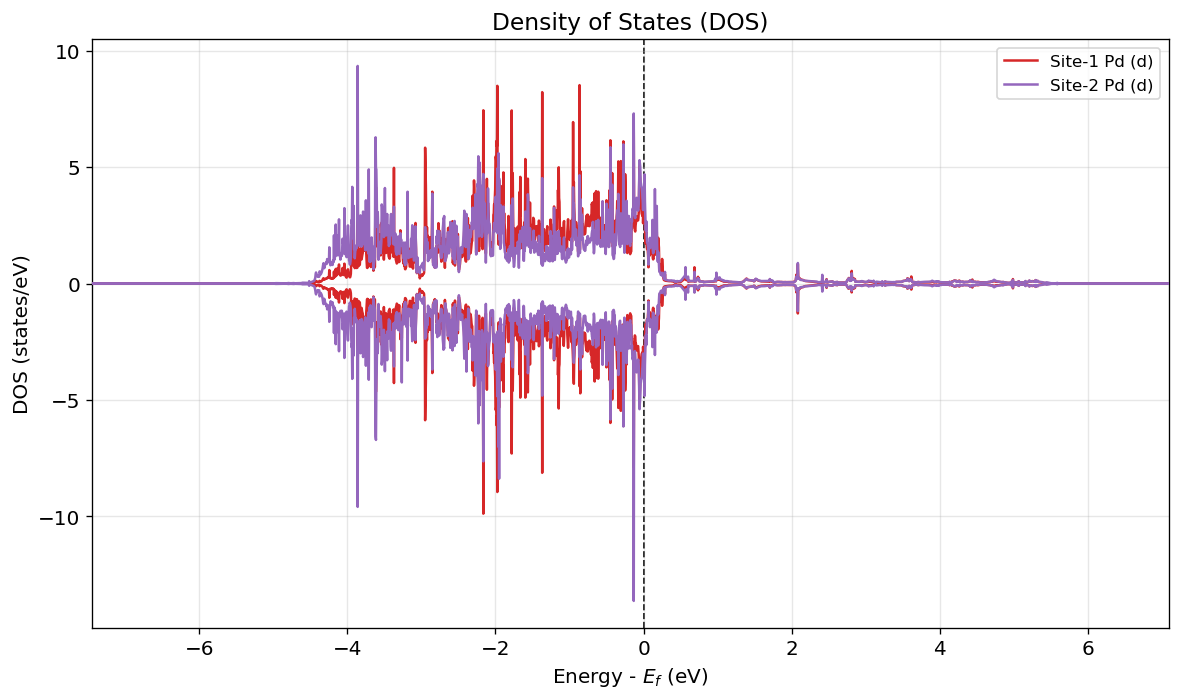


📈 积分计算结果 (d-band center 等):
👉 Site-1 Pd (d):
   - center: -1.4525
   - width: 1.4815
   - skewness: 0.9624
   - kurtosis: 5.8141
   - filling: 0.9099
   - filled_states: 8.5093
   - center_down: -1.452
   - width_down: 1.4839
   - skewness_down: 0.9648
   - kurtosis_down: 5.7986
   - filling_down: 0.9093
   - filled_states_down: 8.4841
   - magnetic_moment: 0.0252
👉 Site-2 Pd (d):
   - center: -1.6997
   - width: 1.6707
   - skewness: 0.8719
   - kurtosis: 4.6825
   - filling: 0.8991
   - filled_states: 8.363
   - center_down: -1.7083
   - width_down: 1.6677
   - skewness_down: 0.876
   - kurtosis_down: 4.6967
   - filling_down: 0.9026
   - filled_states_down: 8.4582
   - magnetic_moment: -0.0952


In [4]:
# 引入绘图库
import matplotlib.pyplot as plt

# 💡 这一行非常关键：告诉 Jupyter 在网页内直接显示图片
%matplotlib inline 

# 1. 检查数据是否存在
if 'dos_data' not in globals() or not dos_data.get('curves'):
    print("⚠️ 警告：dos_data 为空或找不到曲线数据！请确认 Cell 2 已经成功运行。")
else:
    print(f"📊 正在绘制 {len(dos_data['curves'])} 条 PDOS 曲线...")
    
    # 2. 创建画布
    fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
    energies = dos_data['energy']
    
    # 3. 画一条垂直的虚线表示费米能级 (x=0)
    ax.axvline(0, color='black', linestyle='--', linewidth=1, zorder=1)
    
    # 4. 绘制 TDOS (如果有的话，用灰色阴影填充)
    if dos_data.get('tdos'):
        ax.fill_between(energies, dos_data['tdos']['up'], color='gray', alpha=0.2, label='TDOS', zorder=2)
        if 'down' in dos_data['tdos']:
            # 向下自旋取负值
            ax.fill_between(energies, [-x for x in dos_data['tdos']['down']], color='gray', alpha=0.2, zorder=2)
    
    # 5. 循环绘制每一条 PDOS 曲线
    for curve in dos_data['curves']:
        label = curve['label']
        color = curve.get('color', '#333333')
        
        # 画向上自旋 (或非自旋极化)
        ax.plot(energies, curve['dos_up'], label=label, color=color, linewidth=1.5, zorder=3)
        
        # 画向下自旋 (如果有的话，取负值画在 x 轴下方)
        if 'dos_down' in curve:
            ax.plot(energies, [-x for x in curve['dos_down']], color=color, linewidth=1.5, linestyle='-', zorder=3)
            
    # 6. 设置图表格式
    ax.set_xlabel('Energy - $E_f$ (eV)', fontsize=12)
    ax.set_ylabel('DOS (states/eV)', fontsize=12)
    ax.set_title('Density of States (DOS)', fontsize=14)
    ax.set_xlim([energies[0], energies[-1]]) # 设置 X 轴范围为我们截取的范围
    
    # 添加图例
    ax.legend(loc='upper right', frameon=True, fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # 💡 这一行也很关键：强制渲染并显示图表
    plt.tight_layout()
    plt.show()
    
    # 7. 顺便打印一下积分计算的结果 (d-band center 等)
    print("\n📈 积分计算结果 (d-band center 等):")
    for curve in dos_data['curves']:
        print(f"👉 {curve['label']}:")
        for key, value in curve['stats'].items():
            print(f"   - {key}: {value}")


In [5]:
import json
from pathlib import Path

# ⚠️ 请确保这里的路径指向你服务器上包含 LOBSTER 输出文件的真实目录
LOBSTER_DIR = Path("/data2/home/luodh/VOx/VO2/slab/end2/5layer/Ov-magmom/reaction/ICOHP/clean").resolve()

print("==================================================")
print(" 🚀 场景 1: 前端初始加载页面 (极速，无 IO 爆炸)")
print("==================================================")

# 模拟前端发送初始请求 (默认不包含轨道曲线)
response_1 = VaspAnalysisDispatcher.dispatch(
    task_type="cohp",
    work_dir=LOBSTER_DIR,
    n_top_bonds=3,         # 为了测试，只取前 3 个最强键
    erange=[-10, 10]
)

res1_dict = json.loads(response_1)

if res1_dict.get("success"):
    data1 = res1_dict["data"]
    print(f"✅ 初始加载成功！成功获取了前 {data1['n_bonds']} 个最强键。")
    
    # 1. 验证曲线数据是否精简 (不应包含分轨道)
    curve_keys = list(data1['cohp_curves'][0].keys())
    print(f"\n📦 [验证 1] 初始曲线数据列名 (不应包含轨道): \n   {curve_keys}")
    
    # 2. 验证汇总数据是否包含轨道标量 (前端表格需要展示)
    first_bond = data1['icohp_summary'][0]
    target_bond_label = first_bond['bond_label']
    print(f"\n📊 [验证 2] 最强键 [{target_bond_label}] 的汇总信息:")
    print(f"   - 原子对: {first_bond['atom1']} - {first_bond['atom2']}")
    print(f"   - 总 ICOHP: {first_bond['icohp_total']:.3f} eV")
    print(f"   - 包含的轨道及积分值:")
    for orb_name, orb_vals in first_bond['orbitals'].items():
        print(f"       * {orb_name}: UP={orb_vals['icohp_up']:.3f}, DOWN={orb_vals['icohp_down']:.3f}")
else:
    print(f"❌ 初始加载失败: {res1_dict.get('message')}")


print("\n==================================================")
print(f" 🖱️ 场景 2: 用户点击了 '下载键 {target_bond_label} 分轨道数据' 按钮")
print("==================================================")

# 模拟前端发送下载请求 (调用新注册的 cohp_orbital 任务)
response_2 = VaspAnalysisDispatcher.dispatch(
    task_type="cohp_orbital",
    work_dir=LOBSTER_DIR,
    bond_label=target_bond_label,  # 传入刚才获取的最强键标签
    erange=[-10, 10]
)

res2_dict = json.loads(response_2)

if res2_dict.get("success"):
    data2 = res2_dict["data"]
    print(f"✅ 下载数据生成成功！")
    
    # 3. 验证下载数据是否包含分轨道曲线
    download_keys = list(data2.keys())
    print(f"\n📦 [验证 3] 准备导出为 CSV 的数据列 (必须包含分轨道): \n   {download_keys}")
    
    # 打印一下数组长度验证数据完整性
    energy_len = len(data2['energy_eV'])
    print(f"\n📈 数据点数量: {energy_len} points/column")
    print("🎉 测试完美通过！前后端分离的按需加载逻辑已跑通！")
else:
    print(f"❌ 下载请求失败: {res2_dict.get('message')}")


 🚀 场景 1: 前端初始加载页面 (极速，无 IO 爆炸)
✅ 初始加载成功！成功获取了前 3 个最强键。

📦 [验证 1] 初始曲线数据列名 (不应包含轨道): 
   ['energy_eV', '244_up', '244_down', '91_up', '91_down', '40_up', '40_down']

📊 [验证 2] 最强键 [244] 的汇总信息:
   - 原子对: O95 - V210
   - 总 ICOHP: -3.383 eV
   - 包含的轨道及积分值:
       * s-s: UP=-0.627, DOWN=-0.621
       * s-p_y: UP=0.000, DOWN=0.000
       * s-p_z: UP=-0.037, DOWN=-0.036
       * s-p_x: UP=-0.047, DOWN=-0.048
       * s-d_xy: UP=0.000, DOWN=-0.000
       * s-d_yz: UP=-0.000, DOWN=-0.000
       * s-d_z^2: UP=-0.007, DOWN=-0.006
       * s-d_xz: UP=-0.303, DOWN=-0.324
       * s-d_x^2-y^2: UP=-0.094, DOWN=-0.109
       * p_y-s: UP=-0.000, DOWN=-0.000
       * p_y-p_y: UP=-0.008, DOWN=-0.009
       * p_y-p_z: UP=-0.000, DOWN=-0.000
       * p_y-p_x: UP=-0.000, DOWN=-0.000
       * p_y-d_xy: UP=-0.426, DOWN=-0.345
       * p_y-d_yz: UP=-0.238, DOWN=-0.198
       * p_y-d_z^2: UP=-0.000, DOWN=-0.000
       * p_y-d_xz: UP=-0.000, DOWN=-0.000
       * p_y-d_x^2-y^2: UP=-0.000, DOWN=-0.000
       * p_z-